In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from twelvedata import TDClient
from ta.momentum import RSIIndicator
from dotenv import load_dotenv
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report
from scipy import stats

In [2]:
load_dotenv()
API_KEY = os.getenv("TWELVE_DATA_API_KEY")
td = TDClient(apikey=API_KEY)

#pull 15 years of daily SPY data
#long enough to span multiple different market regimes
#long enough to provide sufficient data for each fold during walk-forward validation
spy_ts = td.time_series(
    symbol="SPY",
    interval="1day",
    start_date="2010-01-01",
    end_date="2025-01-01",
    outputsize=5000
)

data = spy_ts.as_pandas()[["close", "volume"]].sort_index()

## Direction Target
### Feature Exploration

The first target will be a binary variable that represents the direction of the SPY ETF price movement from today to tomorrow. It is equal to 1 if the price increases and 0 if the price decreases.

Four categories of features are tested, each summarizing a different aspect of the stock price behaviour.

- **Momentum** (1, 5, 10, 20-day cumulative returns): summarizes recent price direction
- **Realized volatility** (5, 10, 20-day rolling std): summarizes recent price volatility
- **Volume change** (1-day volume pct change): indicates the degree of change in trading participation
- **RSI** (14-day): a nonlinear transformation of momentum

In [3]:
#target: direction of price movement from today to tomorrow (binary)
data["return"] = data["close"].pct_change()
data["target_return"] = data["return"].shift(-1)
data["target_direction"] = (data["target_return"] > 0).astype(int)

#momentum: cumulative returns over each horizon
data["momentum_1"] = data["return"]                      
data["momentum_5"] = data["close"].pct_change(5)          
data["momentum_10"] = data["close"].pct_change(10)        
data["momentum_20"] = data["close"].pct_change(20)

#realized volatility: rolling std of returns over each horizon
data["vol_5"] = data["return"].rolling(5).std()                
data["vol_10"] = data["return"].rolling(10).std()                
data["vol_20"] = data["return"].rolling(20).std()               

#volume: change in volume from yesterday
data["volume_change"] = data["volume"].pct_change()

#RSI: a nonlinear transformation of momentum
data["rsi_14"] = RSIIndicator(close=data["close"], window=14).rsi()

We perform an initial univariate exploration of each feature's relation with the target. This includes their correlation and a two-sample t-test to compare the feature's mean across the two classes of the target.

In [4]:
def univariate_summary(data, feature, target):
    """
    Computes correlation between the feature and the target,
    and a two-sample t-test comparing the feature's mean across the two classes of the target.
    """
    corr = data[feature].corr(data[target])
    group0 = data[data[target] == 0][feature]
    group1 = data[data[target] == 1][feature]
    t_stat, p_val = stats.ttest_ind(group0, group1, nan_policy = "omit", equal_var = False)
    
    return {"Feature": feature, "Correlation": corr, "t_stat": t_stat, "p_value": p_val}

full_feature_set = ["momentum_1", "momentum_5", "momentum_10", "momentum_20",
                "vol_5", "vol_10", "vol_20", "volume_change", "rsi_14"]
model_data_direction = data.dropna(subset = full_feature_set + ["target_direction"])

#dataframe to display the correlation, t-statistic, and p-value for each feature
summary_direction = pd.DataFrame([univariate_summary(model_data_direction, f, "target_direction") for f in full_feature_set])
summary_direction = summary_direction.sort_values("p_value")
print(summary_direction)

         Feature  Correlation    t_stat   p_value
0     momentum_1    -0.026187  1.604056  0.108789
1     momentum_5    -0.018704  1.144394  0.252536
3    momentum_20    -0.013618  0.833154  0.404813
7  volume_change     0.010611 -0.652668  0.514011
6         vol_20    -0.009978  0.611715  0.540764
4          vol_5    -0.009309  0.568499  0.569732
8         rsi_14    -0.009157  0.560324  0.575293
2    momentum_10    -0.007922  0.484797  0.627850
5         vol_10    -0.005093  0.311538  0.755410


All 9 explored features by themselves show low correlation with the target. None of them have significantly different means when grouped by the two classes of the target. To continue, we check whether any of the features combine into a jointly more useful signal.

### Feature Selection

First, we apply walk-forward **L1-regularized** logistic regression on the full candidate feature set, and identify which features are consistently selected across folds. L1-regularization is chosen for its ability to shrink irrelevant feature coefficients to zero, useful since we expect financial data to be highly noisy, and for its ability to handle multicollinearity between features from the same category.

**Five walk-forward folds** are used to balance having enough distinct out-of-sample test periods to assess consistency, against leaving enough data in the earlier folds for model fitting. With 15 years of daily data, this provides at least 625 data points per training fold and 625 data points per test fold. We use an **expanding window** for the training set to maximize the training data available for later folds and improve coefficient stability. The regularization strength C is tested across a wide range **0.01-100** by cross-validation to explore both heavy and light coefficient shrinkage. We **standardize** the features, since this model is sensitive to scale.

To decide which features to retain for the final model, we consider each feature's **selection count** across the five training folds and their **average magnitude when selected**. Features selected inconsistently, or with negligible magnitude, are discarded, leaving a final feature set.

In [5]:
def walk_forward_lasso(X, y, feature_set, class_weight, n_splits=5, Cs=[0.01, 0.1, 1, 10, 100]):
    """
    Applies walk-forward validation with L1-regularized logistic regression (Lasso).
    
    For each fold, the regularization strength C is selected by inner 
    cross-validation on only the training data, 
    keeping the outer test data completely unseen during scaling, parameter selection, and fitting.
    
    Returns:
    - out-of-sample predictions and actuals, pooled across folds
    - a dataframe coef_df of each feature's selection count and average coefficient magnitude when selected
    - a dataframe fold_df of feature coefficients, chosen C, and test accuracy for each fold
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_predictions = []
    all_actuals = []
    fold_accuracies = []
    best_c = []
    
    fold_df = pd.DataFrame(columns=feature_set) 
    
    for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X)):
        #split into training and testing data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        #scale using only training data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        #C selection using cross validation on only training data
        model = LogisticRegressionCV(Cs=Cs, cv=3, penalty="l1", solver="liblinear", #justify parameters
                                       class_weight=class_weight, max_iter=1000)
        
        model.fit(X_train_scaled, y_train)
        
        #feature coefficients and selected C value
        fold_df.loc[fold_num] = model.coef_[0]
        best_c.append(model.C_[0])
        
        #predictions, actuals, and accuracy on the test data
        preds = model.predict(X_test_scaled)
        all_predictions.extend(preds)
        all_actuals.extend(y_test.values)
        fold_accuracies.append(model.score(X_test_scaled, y_test))

    fold_df["best c"] = best_c
    fold_df["accuracies"] = fold_accuracies
    
    #selection count and average coefficient magnitude for each feature
    coef_df = pd.DataFrame(index = feature_set)
    coef_df["selection_count"] = [(fold_df[feat].abs() > 1e-6).sum() for feat in feature_set]
    coef_df["average_when_selected"] = [fold_df[feat].replace(0, np.nan).abs().mean() for feat in feature_set]
    coef_df = coef_df.sort_values(by=["selection_count", "average_when_selected"], ascending=False)
    
    return {
        "predictions": all_predictions,
        "actuals": all_actuals,
        "coef_df": coef_df,
        "fold_df": fold_df
    }

Before we run the model, we must be aware that since the majority class contributes more observations to the objective, a model may learn to heavily favour features that help to identify the majority class. Especially with L1-regularization, this could come at the expense of disregarding features that identify the minority class, resulting in a less comprehensive representation of the factors that drive the target. In fact, a model could decide to discard all features and just predict the majority class every time, and trivially achieve a baseline accuracy equal to the proportion of the majority class.

Since accuracy alone does not reveal where a model's predictive power comes from, we must further check how often the model is actually predicting the majority class, and investigate the classification report for insights into what the model has learned.
If we see that recall for the two classes is heavily unbalanced, we can set the parameter `class_weight="balanced"`, which forces the model to assign equal importance to both classes during the fitting process. This incentivizes the model to select features that discriminate between the two classes instead of just identify the majority class, producing a more informative set of features.

In [6]:
def investigate(results_dict):
    """
    Provides more information on how the model makes predictions.
    
    Tests whether a walk-forward model's pooled out-of-sample accuracy is 
    significantly higher than the naive majority-class baseline.
    
    The p-value represents the probability of observing an accuracy at least 
    as high as the one achieved, under the null hypothesis that the model's 
    true accuracy equals the baseline.
    
    Returns a dict with actual and predicted majority-class rate, accuracy, p-value, and classification report.
    """
    
    actual_rate = np.mean(results_dict["actuals"]) #actual occurence rate of the target
    actual_majority_rate = max(actual_rate, 1 - actual_rate) #actual occurence rate of the majority class
    
    predicted_rate = np.mean(results_dict["predictions"]) #predicted occurence rate of the target
    predicted_majority_rate = max(predicted_rate, 1-predicted_rate) #predicted occurence rate of the majority class (baseline)

    n_correct = sum(p == a for p, a in zip(results_dict["predictions"], results_dict["actuals"]))
    n_total = len(results_dict["actuals"])
    accuracy = n_correct/n_total #accuracy rate of model predictions
    
    result = stats.binomtest(n_correct, n_total, p=actual_majority_rate, alternative="greater") #p-value
    
    cr = classification_report(results_dict["actuals"], results_dict["predictions"], zero_division=0)
    
    print(f"Actual majority rate (minority rate): {actual_majority_rate:.2%} ({1-actual_majority_rate:.2%})")
    print(f"Predicted majority rate (minority rate): {predicted_majority_rate:.2%} ({1-predicted_majority_rate:.2%})")
    print(f"Accuracy: {n_correct/n_total:.2%}")
    print(f"p-value: {result.pvalue:.4f}")
    print(cr)
    
    return {"actual_majority_rate": actual_majority_rate,
            "predicted_majority_rate": predicted_majority_rate,
            "accuracy": accuracy,
            "p_value": result.pvalue,
           "classification_report": cr}

We now run the model and the investigation function on the full feature set.

In [7]:
full_direction_results = walk_forward_lasso(model_data_direction[full_feature_set], model_data_direction["target_direction"], full_feature_set, None)
full_direction_investigation = investigate(full_direction_results)

Actual majority rate (minority rate): 54.98% (45.02%)
Predicted majority rate (minority rate): 99.65% (0.35%)
Accuracy: 55.14%
p-value: 0.4360
              precision    recall  f1-score   support

           0       0.73      0.01      0.01      1407
           1       0.55      1.00      0.71      1718

    accuracy                           0.55      3125
   macro avg       0.64      0.50      0.36      3125
weighted avg       0.63      0.55      0.40      3125



Indeed, when no class weights are imposed, this model defaults to the majority class 99.65% of the time and achieves an accuracy (55.14%) that is not statistically significantly higher than the baseline (54.98%) with a p-value of 0.4360.

Note that the relatively high precision of the minority class (73%) compared to the actual occurence rate (45%) shows some evidence of the ability to identify minority cases. However, the extreme imbalance in the recall for both classes (100% vs 1%) indicates that the model only recognizes a small number of minority cases, and chooses to default to the majority for almost all observations. It is possible that the regularization process discarded features that would have identified more minority cases.

We repeat using balanced class weights to reduce the dominance of the majority class in the fitting objective.

In [8]:
full_direction_results = walk_forward_lasso(model_data_direction[full_feature_set], model_data_direction["target_direction"], full_feature_set, "balanced")
full_direction_investigation = investigate(full_direction_results)

Actual majority rate (minority rate): 54.98% (45.02%)
Predicted majority rate (minority rate): 50.05% (49.95%)
Accuracy: 48.54%
p-value: 1.0000
              precision    recall  f1-score   support

           0       0.44      0.48      0.46      1407
           1       0.54      0.49      0.51      1718

    accuracy                           0.49      3125
   macro avg       0.49      0.49      0.48      3125
weighted avg       0.49      0.49      0.49      3125



As expected, accuracy drops, but the model now predicts the majority class at a rate (50.05%) much closer to the actual rate (54.98%). More importantly, the recall is more balanced (48%, 49%), indicating that the chosen features support discrimination in both directions. Below is a visual comparison of predicted majority rate and recall rate across the unweighted and balanced models.

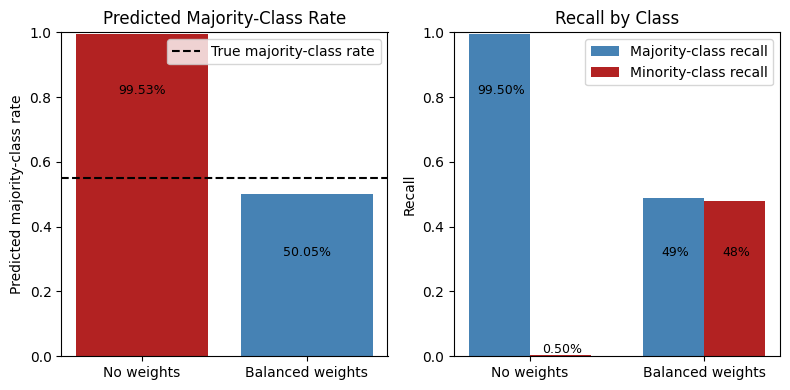

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

#predicted majority-class rate
models = ["No weights", "Balanced weights"]
predicted_majority = [0.9953, 0.5005]

axes[0].bar(models, predicted_majority, color=["firebrick", "steelblue"])
axes[0].text(0, 0.8, f"{0.9953:.2%}", 
            ha="center", va="bottom", fontsize=9)
axes[0].text(1, 0.3, f"{0.5005:.2%}", 
            ha="center", va="bottom", fontsize=9)
axes[0].axhline(0.5498, color="black", linestyle="--", label="True majority-class rate")
axes[0].set_ylabel("Predicted majority-class rate")
axes[0].set_title("Predicted Majority-Class Rate")
axes[0].legend()
axes[0].set_ylim(0, 1)

#recall by class
recall_majority = [0.995, 0.49]
recall_minority = [0.005, 0.48]

x = np.arange(2)
width = 0.35
axes[1].bar(x - width/2, recall_majority, width, label="Majority-class recall", color="steelblue")
axes[1].bar(x + width/2, recall_minority, width, label="Minority-class recall", color="firebrick")
axes[1].text(-0.165, 0.8, f"{0.995:.2%}", 
            ha="center", va="bottom", fontsize=9)
axes[1].text(0.185, 0, f"{0.005:.2%}", 
            ha="center", va="bottom", fontsize=9)
axes[1].text(0.835, 0.3, f"{0.49:.0%}", 
            ha="center", va="bottom", fontsize=9)
axes[1].text(1.185, 0.3, f"{0.48:.0%}", 
            ha="center", va="bottom", fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("Recall")
axes[1].set_title("Recall by Class")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

Below are the feature selection results.

In [10]:
print(full_direction_results["coef_df"])
print(full_direction_results["fold_df"])

               selection_count  average_when_selected
momentum_20                  5               0.070750
momentum_1                   4               0.061774
volume_change                4               0.029702
vol_10                       2               0.159296
vol_5                        1               0.298574
rsi_14                       1               0.285409
momentum_5                   1               0.029082
vol_20                       1               0.023731
momentum_10                  1               0.001805
   momentum_1  momentum_5  momentum_10  momentum_20     vol_5    vol_10  \
0   -0.119839   -0.029082     0.001805    -0.247020  0.298574 -0.315516   
1    0.000000    0.000000     0.000000    -0.009406  0.000000 -0.003077   
2   -0.031550    0.000000     0.000000    -0.035377  0.000000  0.000000   
3   -0.025108    0.000000     0.000000    -0.042080  0.000000  0.000000   
4   -0.070598    0.000000     0.000000    -0.019867  0.000000  0.000000   

     vol_

A reasonable feature selection criterion is to first discard features selected in fewer than **2 of 5 folds**, then use **average coefficient magnitude when selected** to distinguish meaningful from marginal effects among the remaining features. This is justified as a single fold's estimate cannot be distinguished from sampling noise specific to its training period.

For a visual comparison between the features based on the two factors, we show below a scatterplot of selection count against average coefficient magnitude when selected for each feature.

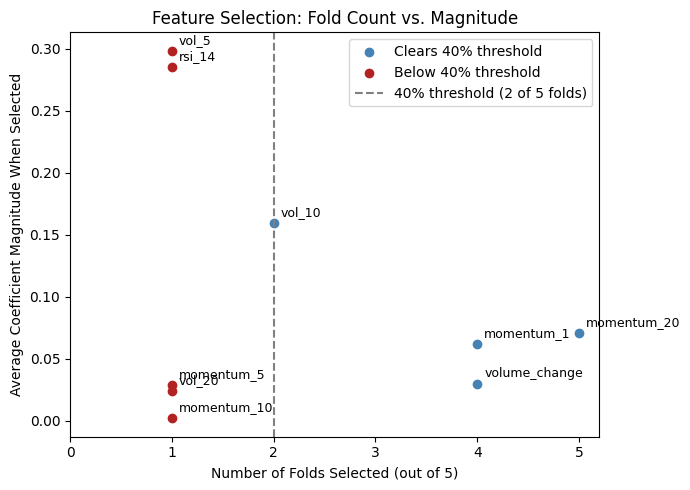

In [11]:
#scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
full_direction_coef_df = full_direction_results["coef_df"]
clears = full_direction_coef_df["selection_count"]>=2

ax.scatter(full_direction_coef_df.loc[clears, "selection_count"], full_direction_coef_df.loc[clears, "average_when_selected"], 
           color="steelblue", label="Clears 40% threshold")
ax.scatter(full_direction_coef_df.loc[~clears, "selection_count"], full_direction_coef_df.loc[~clears, "average_when_selected"], 
           color="firebrick", label="Below 40% threshold")

for feat in full_direction_coef_df.index:
    ax.annotate(feat, (full_direction_coef_df.loc[feat, "selection_count"], full_direction_coef_df.loc[feat, "average_when_selected"]),
                textcoords="offset points", xytext=(5,5), fontsize=9)

ax.axvline(2, color="gray", linestyle="--", label="40% threshold (2 of 5 folds)")
ax.set_xticks(range(0, 6))
ax.set_xlabel("Number of Folds Selected (out of 5)")
ax.set_ylabel("Average Coefficient Magnitude When Selected")
ax.set_title("Feature Selection: Fold Count vs. Magnitude")
ax.legend()
plt.tight_layout()
plt.show()

Only **4 features** meet the 40% threshold. Out of these, the one with the largest average coefficient magnitude of 0.16 is `vol_10`. However, it was only selected twice, and by examining `fold_df`, we observe that its average is driven entirely by its large coefficient magnitude of 0.32 in the first fold. We also note that this first fold selected a large regularization parameter C=10 corresponding to a weak penalty, compared to C=0.1 in folds 2-5. Given that the first fold has the most limited training data, its estimate is least reliable, and we conclude that the relatively large `vol_10` coefficient is likely a result of regularization instability due to a smaller sample, and **should be excluded**.

The remaining three features `momentum_20`, `momentum_1`, and `volume_change` were selected more consistently. Even though they display the same pattern of showing a noticeable decrease in coefficient magnitude from fold 1 (C=10) to folds 2-5 (C=0.1), we retain them since they have high selection rates even excluding fold 1.

However, we note that their already-small average magnitudes are in fact inflated by their weakly regularized fold 1 coefficients, showing that even the most consistently selected features carry a very weak estimated relationship with next-day direction.

In [12]:
#final feature set
final_direction_feature_set = ["momentum_1", "momentum_20", "volume_change"]

### Investigating Feature Selection: Momentum Correlations
Before running the final model, it is worth noting that `momentum_5` and `momentum_10` were selected in only 1 of 5 folds, while `momentum_1` and `momentum_20` were selected in almost all folds, even though they contain comparable information. This likely reflects how the L1 penalty identifies some multicollinearity between the four momentum features and shrinks them to zero as appropriate.

To investigate this, correlations between the four momentum features are shown below.

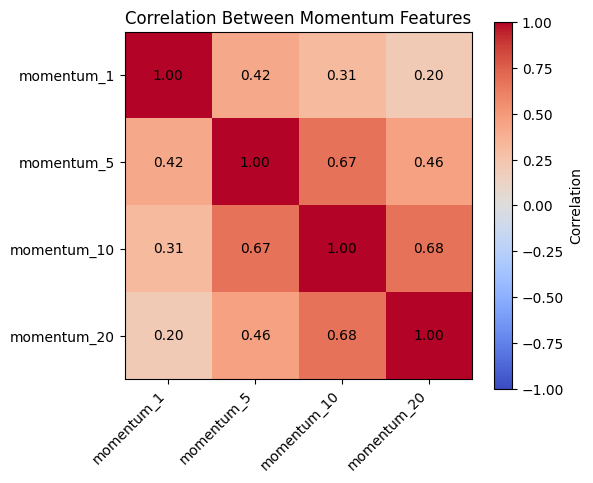

In [13]:
corr_matrix = model_data_direction[["momentum_1", "momentum_5", "momentum_10", "momentum_20"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# axis labels using actual feature names
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# annotate each cell with its actual value
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", 
                 ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, label="Correlation")
plt.title("Correlation Between Momentum Features")
plt.tight_layout()
plt.show()

It is not surprising that we see high correlations between consecutive features. We also notice that `momentum_5` is highly correlated to not only its neighbours, but also to `momentum_20`. It is likely that `momentum_1` was selected because it contained the most unique information, and `momentum_20` was selected because it was the least correlated with `momentum_1`. This is consistent with Lasso favoring one representative from each group of related features, even if `momentum_5` and `momentum_10` do carry information individually.

### Final Results

The final feature set will be evaluated using the same walk-forward L1-regularized 
logistic regression structure. During feature selection, balanced weighting was a corrective measure for cases 
where unweighted fitting fails to meaningfully use minority-class information and hence fails to fairly evaluate each feature's discriminative potential.

However, the goal of this analysis is to test whether the selected features can improve 
predictive accuracy over the naive baseline, that is, the true majority-class occurence rate. For this purpose, unweighted fitting is used for the 
final model, since it treats every observation equally during fitting, just as accuracy counts every correct observation equally.

In [14]:
final_direction_results = walk_forward_lasso(model_data_direction[final_direction_feature_set], model_data_direction["target_direction"], final_direction_feature_set, None)
final_direction_investigation = investigate(final_direction_results)

print(final_direction_results["coef_df"])
print(final_direction_results["fold_df"])

Actual majority rate (minority rate): 54.98% (45.02%)
Predicted majority rate (minority rate): 98.46% (1.54%)
Accuracy: 54.78%
p-value: 0.5926
              precision    recall  f1-score   support

           0       0.44      0.01      0.03      1407
           1       0.55      0.98      0.71      1718

    accuracy                           0.55      3125
   macro avg       0.49      0.50      0.37      3125
weighted avg       0.50      0.55      0.40      3125

               selection_count  average_when_selected
momentum_1                   5               0.045582
momentum_20                  5               0.034163
volume_change                5               0.028826
   momentum_1  momentum_20  volume_change  best c  accuracies
0   -0.072547    -0.026571      -0.083463    10.0      0.5568
1   -0.018196    -0.033620      -0.015045     1.0      0.5184
2   -0.031487    -0.035238       0.026293     0.1      0.5648
3   -0.035084    -0.055689       0.018258   100.0      0.5584
4   

In this final model, the selected C value varies without a clear trend across folds, yet coefficient magnitudes and accuracy remain relatively stable across folds. This indicates that while they may be small, their estimated relationships with the target are robust to the specific regularization strength chosen.

However, the model still decides to predict the majority class 98.46% of the time. As with the full unweighted model, this near-total reliance on the majority class explains its failure to beat baseline.

### Conclusion

The final direction model, using `momentum_1`, `momentum_20`, and 
`volume_change`, achieved an out-of-sample accuracy of **54.78%**, below the naive majority-class baseline 
of **54.98%**, with a p-value of 0.5926, providing no evidence of predictive skill. This is 
consistent with the univariate exploratory results earlier, where no candidate 
feature showed a significant relationship with next-day direction. It also demonstrates the concept that
daily price direction in a highly liquid and heavily traded equity 
such as SPY is expected to be efficiently priced, since any edge from simple and publicly 
available features such as the ones explored would likely already be arbitraged away by other market 
participants.

The three features used were the most defensible based on the selection criteria, 
yet the resulting model still failed to beat baseline. We note that the coefficient 
magnitudes in the final direction model were substantially smaller than those in 
the volatility model (see below), suggesting that while the model identified a small, non-zero relationship with next-day direction, it was too weak, given the available sample size and market noise, to push prediction probabilities over the decision threshold and produce a practically detectable predictive edge. This demonstrates the idea that consistent selection under L1 regularization is not sufficient evidence of predictive power. Instead, we must still check out-of-sample accuracy directly.

The remainder of this project tests the same approach 
against a different target: **relative volatility**, motivated by the 
fact that well-documented phenomena such as the leverage effect and volatility clustering may make this target more predictable than direction.

## Volatility Target
### Feature Exploration

This target will be a binary variable that represents whether the SPY ETF return volatility in the upcoming 5 trading days (1 week) will be greater or less than the return volatility in the past 60 trading days (~1 fiscal quarter).

The same four categories of features are tested, since they were initially taken to summarize different aspects of the stock price behaviour, regardless of the target. In this case, these categories also link directly to stylized facts about volatility which are well-known in the literature.

In particular, the momentum category tests the leverage effect, which is the tendency for price declines to precede elevated volatility, and price gains to precede calmer conditions. The RSI feature does this as well, since it is a nonlinear transformation of recent momentum. The volatility category tests volatility clustering, which is the tendency for high and low volatility periods to persist. The volume feature tests whether a sudden shift in trading participation could reflect disagreement or uncertainty among market participants, which could precede an increase in volatility.

In [15]:
#target: whether upcoming return volatility is greater than a recent volatility benchmark (binary)
data["future_vol_5"] = data["return"].rolling(5).std().shift(-5) #return volatility in the trading week ahead (5 days)
data["trailing_vol_60"] = data["return"].rolling(60).std() #return volatility in the past fiscal quarter (~60 days)
data["target_high_vol"] = (data["future_vol_5"] > data["trailing_vol_60"]).astype(int)

model_data_volatility = data.dropna(subset = full_feature_set + ["target_high_vol"])

#dataframe to display the correlation, t-statistic, and p-value for each feature
summary_volatility = pd.DataFrame([univariate_summary(model_data_volatility, f, "target_high_vol") for f in full_feature_set])
summary_volatility = summary_volatility.sort_values("p_value")
print(summary_volatility)

         Feature  Correlation     t_stat       p_value
2    momentum_10    -0.346727  20.967595  3.419702e-89
8         rsi_14    -0.318922  19.030967  7.195399e-75
3    momentum_20    -0.301833  18.143883  7.867777e-69
1     momentum_5    -0.291515  17.257927  1.065720e-62
0     momentum_1    -0.144393   8.169557  5.239175e-16
4          vol_5     0.124972  -6.863289  8.967104e-12
5         vol_10     0.086294  -4.798584  1.711874e-06
7  volume_change     0.039561  -2.386831  1.706411e-02
6         vol_20     0.007637  -0.450869  6.521231e-01


As can be seen, a few of the explored features by themselves already show non-trivial correlation with the volatility target, and most of the features have statistically significantly different means when grouped by the two classes of the target. Again, we check whether any of the features combine into a jointly more useful signal.

### Feature Selection

As before, we use walk-forward Lasso to check if the features are jointly more predictive, and to check for multicollinearity. 

In [16]:
full_volatility_results = walk_forward_lasso(model_data_volatility[full_feature_set], model_data_volatility["target_high_vol"], full_feature_set, None)
full_volatility_investigation = investigate(full_volatility_results)

Actual majority rate (minority rate): 64.61% (35.39%)
Predicted majority rate (minority rate): 77.79% (22.21%)
Accuracy: 70.88%
p-value: 0.0000
              precision    recall  f1-score   support

           0       0.73      0.88      0.80      2019
           1       0.64      0.40      0.49      1106

    accuracy                           0.71      3125
   macro avg       0.68      0.64      0.64      3125
weighted avg       0.70      0.71      0.69      3125



The unweighted model achieves an accuracy of 70.88%, clearing the baseline 
(64.61%) confidently by 6.27 percentage points. The predicted majority-class rate 
(77.79%) is elevated relative to the true rate (64.61%) but far from the collapse into majority-class prediction seen for direction. 

From the recall on the minority class (40%), we infer that the unweighted model must actually be using information from the features to identify a decent portion of true high-volatility days. The precision on the minority class (64%) is also high relative to the true minority rate (35%), showing that it makes these minority predictions with some confidence. Even though the performance is still asymmetric, the model has demonstrated good predictive ability for both classes. There is no need to set balanced class weights, and we retain this model as the basis for feature selection.

In [17]:
print(full_volatility_results["coef_df"])
print(full_volatility_results["fold_df"])

               selection_count  average_when_selected
vol_20                       5               0.451446
momentum_10                  5               0.318418
momentum_20                  5               0.271997
rsi_14                       5               0.247772
momentum_5                   5               0.211557
momentum_1                   4               0.050604
vol_10                       3               0.313749
vol_5                        3               0.049909
volume_change                3               0.020843
   momentum_1  momentum_5  momentum_10  momentum_20     vol_5    vol_10  \
0   -0.015245   -0.164446    -0.262913    -0.200355  0.000000  0.000000   
1    0.000000   -0.206316    -0.277506    -0.089255  0.025342  0.000000   
2   -0.051039   -0.277024    -0.308605    -0.215314  0.000000  0.341864   
3   -0.076331   -0.216732    -0.347181    -0.331551  0.028447  0.341430   
4   -0.059802   -0.193268    -0.395885    -0.523510  0.095939  0.257954   

     vol_

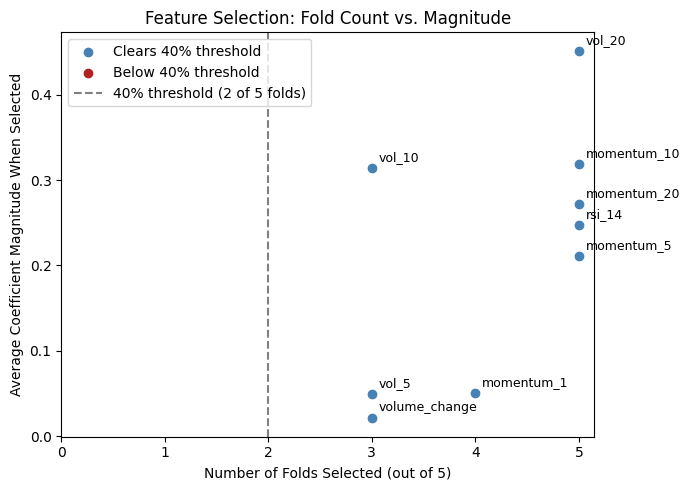

In [18]:
#scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
full_volatility_coef_df = full_volatility_results["coef_df"]
clears = full_volatility_coef_df["selection_count"]>=2

ax.scatter(full_volatility_coef_df.loc[clears, "selection_count"], full_volatility_coef_df.loc[clears, "average_when_selected"], 
           color="steelblue", label="Clears 40% threshold")
ax.scatter(full_volatility_coef_df.loc[~clears, "selection_count"], full_volatility_coef_df.loc[~clears, "average_when_selected"], 
           color="firebrick", label="Below 40% threshold")

for feat in full_volatility_coef_df.index:
    ax.annotate(feat, (full_volatility_coef_df.loc[feat, "selection_count"], full_volatility_coef_df.loc[feat, "average_when_selected"]),
                textcoords="offset points", xytext=(5,5), fontsize=9)

ax.axvline(2, color="gray", linestyle="--", label="40% threshold (2 of 5 folds)")
ax.set_xticks(range(0, 6))
ax.set_xlabel("Number of Folds Selected (out of 5)")
ax.set_ylabel("Average Coefficient Magnitude When Selected")
ax.set_title("Feature Selection: Fold Count vs. Magnitude")
ax.legend()
plt.tight_layout()
plt.show()

All 9 features clear the criteria of being selected at least 2 of 5 folds. However, we notice that 3 of the features are relatively close to 0 on average: `volume_change`, `vol_5`, and `momentum_1`. 

It is reasonable to perform feature selection based on coefficient magnitude. We discard the 3 lowest features as negligible contributors, and retain the remaining 6 features for the final model: `vol_20`, `vol_10`, `momentum_10`, `momentum_20`, `rsi_14`, and `momentum_5`.

Note that among momentum and volatility features, the shortest-horizon versions 
(`momentum_1`, `vol_5`) were dropped in favor of longer-horizon measures 
(`momentum_5/10/20`, `vol_10/20`), suggesting the volatility 
target is better captured by information over longer 
backward-looking windows.

In [19]:
#final feature set
final_volatility_feature_set = ["momentum_5", "momentum_10", "momentum_20", "vol_10", "vol_20", "rsi_14"]

### Final Results

In [20]:
final_volatility_results = walk_forward_lasso(model_data_volatility[final_volatility_feature_set], model_data_volatility["target_high_vol"], final_volatility_feature_set, None)
final_volatility_investigation = investigate(final_volatility_results)

print(final_volatility_results["coef_df"])
print(final_volatility_results["fold_df"])

Actual majority rate (minority rate): 64.61% (35.39%)
Predicted majority rate (minority rate): 76.74% (23.26%)
Accuracy: 71.17%
p-value: 0.0000
              precision    recall  f1-score   support

           0       0.73      0.87      0.80      2019
           1       0.64      0.42      0.51      1106

    accuracy                           0.71      3125
   macro avg       0.69      0.65      0.65      3125
weighted avg       0.70      0.71      0.69      3125

             selection_count  average_when_selected
vol_20                     5               0.676213
vol_10                     5               0.413929
rsi_14                     5               0.289950
momentum_10                5               0.285413
momentum_20                5               0.271693
momentum_5                 5               0.253510
   momentum_5  momentum_10  momentum_20    vol_10    vol_20    rsi_14  best c  \
0   -0.242718    -0.162359    -0.221823  0.579167 -0.776855 -0.392700     1.0   
1  

The three momentum features 5, 10, and 20, carry negative coefficients. This is consistent with the leverage-effect hypothesis: negative price momentum is associated with higher predicted probability of elevated near-term volatility. We note that since `rsi_14` is a nonlinear encoding of momentum, it also makes sense that it has a negative coefficient.

On another note, given the earlier finding that Lasso tends to favor one representative from 
a pair of correlated features, it is interesting to see `vol_10` and `vol_20` both retained, and with 
the two largest coefficients, in the final model. It is even more interesting that `vol_10` and `vol_20` are both volatility features, yet `vol_10` consistently receives a large positive coefficient, while `vol_20` consistently receives a large negative coefficient. According to the volatility-clustering hypothesis, which is that high and low volatility days tend to persist, it makes sense for a volatility feature to have a positive coefficient, which only explains `vol_10`.

Below, we explore further and explain the negative coefficient of `vol_20`.

### Investigating `vol_10` and `vol_20`: The Suppressor Effect

In [21]:
print("Correlation between vol_10 and vol_20:", round(model_data_direction[["vol_10", "vol_20"]].corr().iloc[0, 1], 2))

Correlation between vol_10 and vol_20: 0.91


We report a high positive correlation of 0.91 between `vol_10` and `vol_20`.

This is consistent with a suppressor variable effect, in particular **classical suppression**. `vol_20` by itself shows no linear relationship with the target (r = 0.008, p = 0.65), while `vol_10` shows 
a weak but highly significant relationship (r = 0.086, 
p < 0.001). The model uses `vol_20`'s negative 
coefficient to net out some component common to both features, isolating the portion of `vol_10` that is relevant to the target and hence generating a stronger predictive signal that is not evident from either feature alone. 

### Volatility: Conclusion

The final resulting model achieved an out-of-sample accuracy of 71.17%
against a naive majority-class baseline of 64.61%, an edge 
of more than 6 percentage points, highly statistically significant (p < 0.001). 
Precision is high and recall is reasonable for both classes.

This result is a clear contrast to the direction model, which failed to 
beat the baseline accuracy using its selected features. The distinction is 
consistent with the economic rationale motivating each feature: momentum and volatility-based measures 
are hypothesized to predict the 
magnitude of future price movement (by the leverage effect, volatility 
clustering, and participation-shock mechanisms) rather than its direction. In addition, while daily price direction for SPY may be heavily traded, its volatility is harder to trade directly without options or more sophisticated instruments, allowing it to retain a more detectable relationship with its recent price behaviour.

We note that the only feature selected for both targets was `momentum_20`, and that its coefficient is much larger here (0.29) than in the previous model (0.03). This is consistent with the idea that its relationship with the direction target was nonzero but too weak to utilise.

### Confound Analysis

Before treating this as a genuine signal, some further analysis is needed. Since the target itself is defined relative to `trailing_vol_60` (volatility in the past 60 trading days), the model's predictive power could just be reflecting this relationship instead of information from the other features. In addition, two of the selected features, `vol_10` and `vol_20`, are also related to `trailing_vol_60`, so should be checked as well.

To isolate the source of predictive power, the six selected features are split into two groups: volatility features (`vol_10` and `vol_20`) and non-volatility features (`momentum_5`, `momentum_10`, `momentum_20`, `rsi_14`). These will be tested separately, and `trailing_vol_60` will also be tested by itself.

To match the final volatility model, we will use unweighted fitting throughout, ensuring that any differences in accuracy, precision, and recall reflects only the feature set being tested.

In [22]:
volatility_features = ["vol_10", "vol_20"] #volatility features that were selected
non_volatility_features = ["momentum_5", "momentum_10", "momentum_20", "rsi_14"] #non-volatility features that were selected
benchmark_feature = ["trailing_vol_60"] #this was explicitly used to construct the target

In [23]:
#volatility features that were selected
model_data_vol_features = data.dropna(subset = volatility_features + ["target_high_vol"])

vol_features_results = walk_forward_lasso(model_data_vol_features[volatility_features], model_data_vol_features["target_high_vol"], volatility_features, None)
vol_features_investigation = investigate(vol_features_results)

print(vol_features_results["coef_df"])
print(vol_features_results["fold_df"])

Actual majority rate (minority rate): 64.61% (35.39%)
Predicted majority rate (minority rate): 95.33% (4.67%)
Accuracy: 64.74%
p-value: 0.4486
              precision    recall  f1-score   support

           0       0.65      0.96      0.78      2019
           1       0.51      0.07      0.12      1106

    accuracy                           0.65      3125
   macro avg       0.58      0.52      0.45      3125
weighted avg       0.60      0.65      0.55      3125

        selection_count  average_when_selected
vol_10                3               1.015757
vol_20                3               0.901420
     vol_10    vol_20  best c  accuracies
0  0.000000  0.000000    0.01      0.6384
1  0.000000  0.000000    0.01      0.6624
2  0.880162 -0.764991   10.00      0.6624
3  0.912226 -0.798532    1.00      0.6432
4  1.254884 -1.140738   10.00      0.6304


Just as in the final model, the predictor feature `vol_10` has a large positive coefficient when selected, and always comes in combination with its suppressor feature `vol_20`, which is given a large negative coefficient.

This model shows some evidence of very weak discriminative power. While it defaults to the majority class 95.33% of the time and only correctly identifies 7% of all minority cases, it does achieve a precision of 51% on the minority class, much higher than the actual occurence rate 35%. This suggests that it has learned some signal for identifying the minority case, but utilises it very conservatively, resulting in an accuracy that is not statistically significantly higher than baseline (p = 0.4486).

We note that the model completely discards both features in the first two folds, meaning that all predictions in the first two folds must have been the majority class. This supports the idea that the model may have achieved a higher minority recall rate by being less conservative in using the features to identify minority signals. However, this is unlikely to increase accuracy as shown by the accuracy remaining roughly constant across the folds.

Overall, it seems that the volatility features contributed relatively little to the final model's predictive power. However, we hypothesize that dropping the volatility features from the final model would at least cause it to lose some ability to detect the minority class. 

In [24]:
#non-volatility features that were selected
model_data_non_vol_features = data.dropna(subset = non_volatility_features + ["target_high_vol"])

non_vol_features_results = walk_forward_lasso(model_data_non_vol_features[non_volatility_features], model_data_non_vol_features["target_high_vol"], non_volatility_features, None)
non_vol_features_investigation = investigate(non_vol_features_results)

print(non_vol_features_results["coef_df"])
print(non_vol_features_results["fold_df"])

Actual majority rate (minority rate): 64.61% (35.39%)
Predicted majority rate (minority rate): 79.20% (20.80%)
Accuracy: 70.43%
p-value: 0.0000
              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2019
           1       0.64      0.38      0.47      1106

    accuracy                           0.70      3125
   macro avg       0.68      0.63      0.63      3125
weighted avg       0.69      0.70      0.68      3125

             selection_count  average_when_selected
momentum_10                5               0.383767
momentum_5                 5               0.201322
rsi_14                     5               0.154681
momentum_20                4               0.166777
   momentum_5  momentum_10  momentum_20    rsi_14  best c  accuracies
0   -0.203888    -0.294973    -0.166092 -0.197779    0.10      0.6864
1   -0.290494    -0.373010    -0.059291 -0.296715    1.00      0.7152
2   -0.113711    -0.294570     0.000000 -0.209912    0.01  

Comparing against the final volatility model, this model has increased its rate of predicting the majority class from 76.74% to 79.20%, and the minority class recall rate has dropped from 42% to 38%, resulting in a very small drop in accuracy from 71.17% to 70.43%. Other metrics are mostly unchanged.

This indeed supports the idea that the volatility features had been contributing a very small amount in identifying the minority class. Clearly, the momentum features account for the large majority of the full model's predictive power.

In [25]:
#trailing_vol_60
model_data_benchmark_feature = data.dropna(subset = benchmark_feature + ["target_high_vol"])
summary_benchmark_feature = pd.DataFrame([univariate_summary(model_data_benchmark_feature, f, "target_high_vol") for f in benchmark_feature])

print(summary_benchmark_feature)

           Feature  Correlation    t_stat       p_value
0  trailing_vol_60     -0.13436  8.948356  5.764296e-19


In [26]:
benchmark_feature_results = walk_forward_lasso(model_data_benchmark_feature[benchmark_feature], model_data_benchmark_feature["target_high_vol"], benchmark_feature, None)
benchmark_feature_investigation = investigate(benchmark_feature_results)

print(benchmark_feature_results["coef_df"])
print(benchmark_feature_results["fold_df"])

Actual majority rate (minority rate): 64.43% (35.57%)
Predicted majority rate (minority rate): 100.00% (0.00%)
Accuracy: 64.43%
p-value: 0.5082
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1994
           1       0.00      0.00      0.00      1101

    accuracy                           0.64      3095
   macro avg       0.32      0.50      0.39      3095
weighted avg       0.42      0.64      0.50      3095

                 selection_count  average_when_selected
trailing_vol_60                4               0.143515
   trailing_vol_60  best c  accuracies
0         0.000000    0.01    0.634895
1        -0.296446   10.00    0.654281
2        -0.025223    0.01    0.646204
3        -0.120813    0.01    0.639742
4        -0.131578    0.01    0.646204


This model completely defaults to the majority class, resulting in 
a recall of 100% for the majority and 0% for the minority, and an accuracy exactly equal to baseline. This is despite the model choosing to keep the feature in 4 of the 5 folds, suggesting that having this feature improves the prediction probabilities, but that its signal is too weak to push probabilities over the threshold. Ultimately, the model extracts no discriminative information from this feature at all. We are no longer concerned that the final model's performance may be largely due to the target being inversely proportional to `trailing_vol_60`. 

Recall that `trailing_vol_60` did show a statistically significant correlation with the target (r = -0.13, p < 0.001). This again demonstrates that a strong full-sample statistical association does not guarantee any actual out-of-sample predictive power.

### Synthesis and Insights

We have tested 4 models in total. Below is a table to summarize their accuracies and compare them to their respective baselines.

| Model | Features | Accuracy | vs. Baseline |
|---|---|---|---|
| Final Model | momentum_5, momentum_10, momentum_20, rsi_14, vol_10, vol_20 | 71.17% | +6.56 pp |
| Volatility | vol_10, vol_20 | 64.74% | +0.13 pp |
| Non-volatility | momentum_5, momentum_10, momentum_20, rsi_14 | 70.43% | +5.82 pp |
| Benchmark | trailing_vol_60 | 64.43% | +0.00 pp |

This section has shown that the relationship between the target and past volatility information is not the primary driver of the final model's predictive power. In particular, `trailing_vol_60` does not seem to contribute at all.

Below, we compare the accuracies, predicted majority-class rates, and minority recall rates of the first three models.

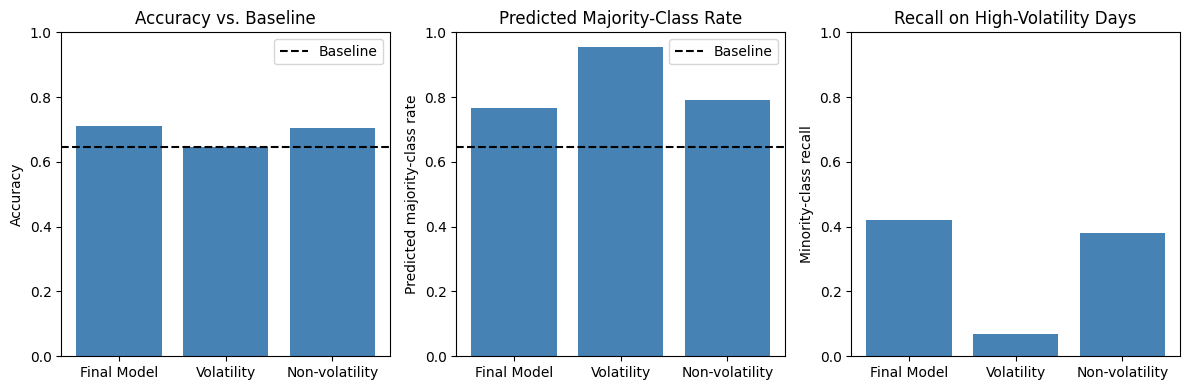

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models = ["Final Model", "Volatility", "Non-volatility"]

#accuracy vs baseline
accuracies = [0.7117, 0.6474, 0.7043]
baseline = 0.6461
axes[0].bar(models, accuracies, color="steelblue")
axes[0].axhline(baseline, color="black", linestyle="--", label="Baseline")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. Baseline")
axes[0].set_ylim(0, 1)
axes[0].legend()

#predicted majority-class rate
predicted_majority = [0.7674, 0.9533, 0.7920]
true_majority = 0.6461
axes[1].bar(models, predicted_majority, color="steelblue")
axes[1].axhline(true_majority, color="black", linestyle="--", label="Baseline")
axes[1].set_ylabel("Predicted majority-class rate")
axes[1].set_title("Predicted Majority-Class Rate")
axes[1].set_ylim(0, 1)
axes[1].legend()

#recall on minority class
recall_minority = [0.42, 0.07, 0.38]
axes[2].bar(models, recall_minority, color="steelblue")
axes[2].set_ylabel("Minority-class recall")
axes[2].set_title("Recall on High-Volatility Days")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

A direct comparison between these three models provides further insights on the economics behind the features. From the non-volatility model, we see again that the momentum features are assigned negative coefficients due to the leverage effect. From the volatility model, we also see again that `vol_10` has a positive coefficient, consistent with volatility clustering, while `vol_20` has a negative coefficient as its suppressor feature.

We also gained new insights into the mathematical role of the momentum and volatility features. The momentum features were the main drivers that discriminate between upcoming high-volatility and low-volatility periods, achieving an accuracy of 70.43%, within one percentage point of the full model accuracy 71.17%. Meanwhile, the volatility features did not provide much additional help in identifying low-volatility periods, but instead contribute to identifying high-volatility periods.

This provides more detail on the volatility clustering effect. While we may not be able to reliably identify when upcoming volatility will decrease by looking at past volatility, we can identify when it is likely to increase. However, despite the volatility features containing real information, the weakness of the signal, combined with the class imbalance, means that by themselves, they are unable to achieve an accuracy higher than baseline.